In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

W/H invalids weights: 8394x10793. Skipping.
Par não encontrado: 7.jpg, 8.jpg


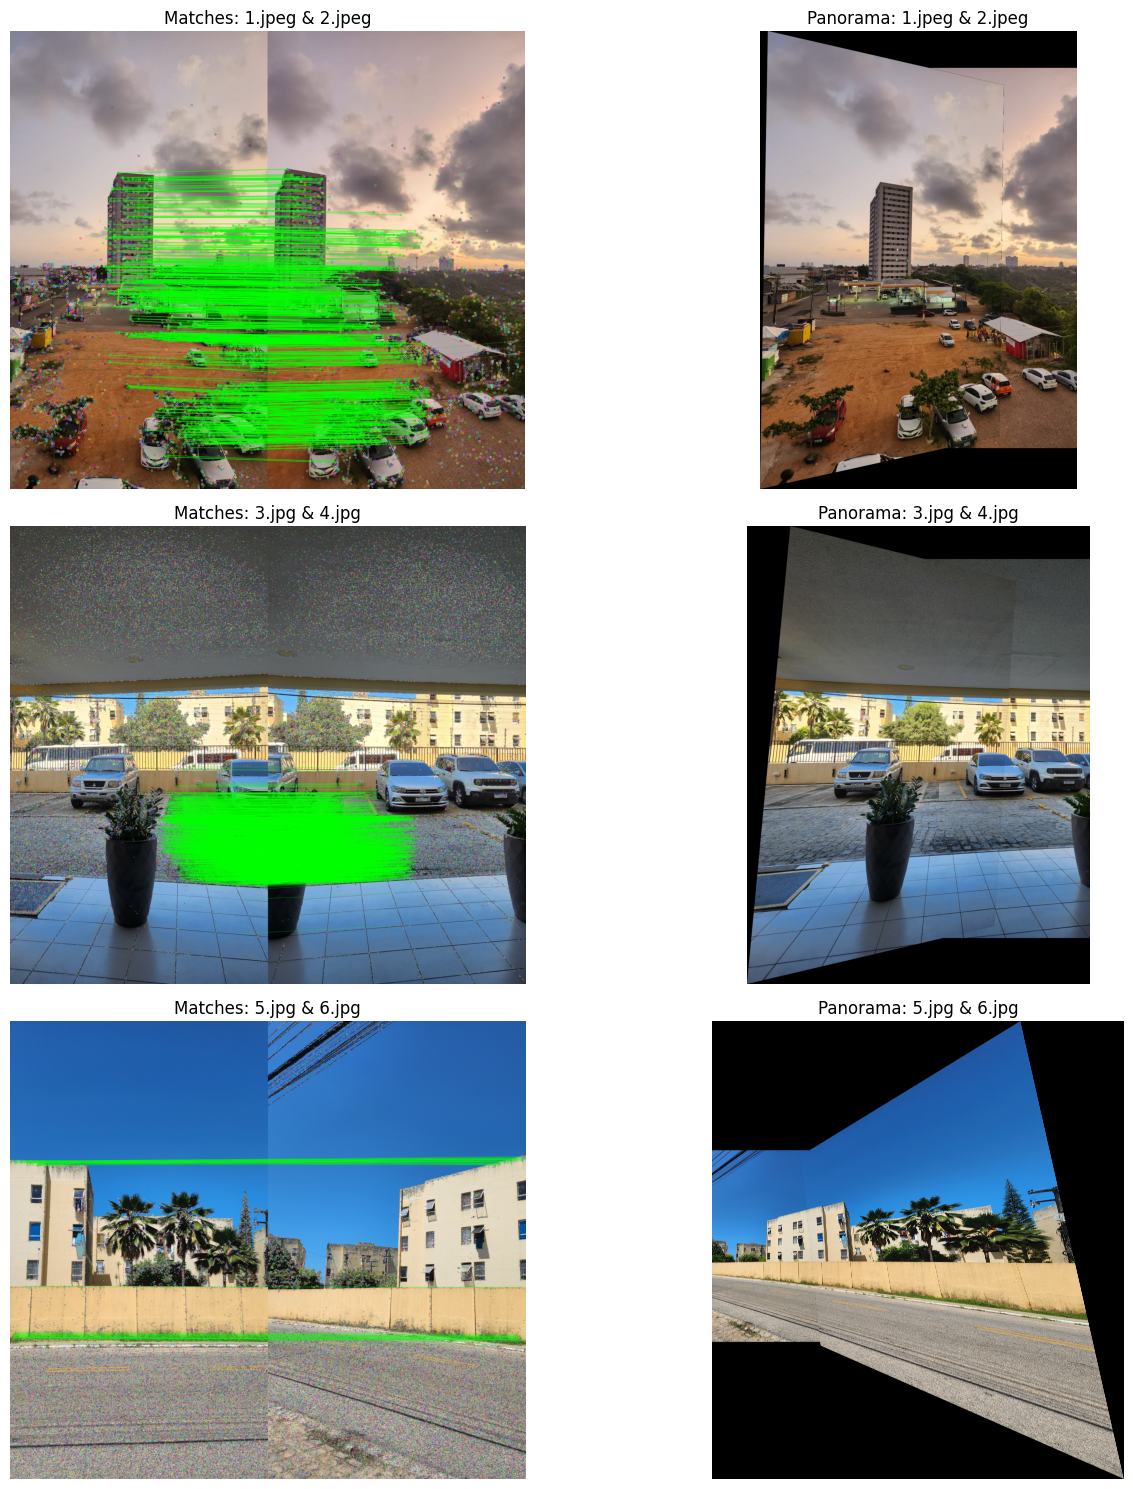

In [ ]:
# Second cell (panorama functions)
def load_images_from_folder(folder_path):
    image_files = glob(os.path.join(folder_path, '*.jpg')) + glob(os.path.join(folder_path, '*.jpeg')) + glob(os.path.join(folder_path, '*.png'))
    
    image_files.sort(key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))
    
    images = []
    for file_path in image_files:
        img = cv2.imread(file_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append((os.path.basename(file_path), img))
    return images

def find_features_and_matches(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    sift = cv2.SIFT_create()
    keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(descriptors1, descriptors2, k=2)
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
    return good_matches, keypoints1, keypoints2, descriptors1, descriptors2

def compute_homography(img1, img2, show_matches=True):
    good_matches, kp1, kp2, _, _ = find_features_and_matches(img1, img2)
    if len(good_matches) < 4:
        return None, None
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    match_visualization = None
    if show_matches:
        matchesMask = mask.ravel().tolist()
        draw_params = dict(matchColor=(0, 255, 0), singlePointColor=None, matchesMask=matchesMask, flags=cv2.DrawMatchesFlags_DEFAULT)
        img1_bgr = cv2.cvtColor(img1, cv2.COLOR_RGB2BGR)
        img2_bgr = cv2.cvtColor(img2, cv2.COLOR_RGB2BGR)
        match_visualization = cv2.drawMatches(img1_bgr, kp1, img2_bgr, kp2, good_matches, None, **draw_params)
        match_visualization = cv2.cvtColor(match_visualization, cv2.COLOR_BGR2RGB)
    return H, match_visualization

def create_panorama(img1, img2):
    H, match_visualization = compute_homography(img1, img2, show_matches=True)
    if H is None:
        print("Sem homografia.")
        return None, match_visualization

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    corners2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

    corners1_transformed = cv2.perspectiveTransform(corners1, H)

    all_corners = np.concatenate((corners1_transformed, corners2), axis=0)

    x_min, y_min = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    x_max, y_max = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation_dist = [-x_min, -y_min]
    H_translation = np.array([[1, 0, translation_dist[0]],
                              [0, 1, translation_dist[1]],
                              [0, 0, 1]], dtype=np.float32)

    panorama_width = x_max - x_min
    panorama_height = y_max - y_min

    if panorama_width <= 0 or panorama_height <= 0 or panorama_width > 10000 or panorama_height > 10000:
        print(f"W/H invalids weights: {panorama_width}x{panorama_height}. Skipping.")
        return None, match_visualization

    img2_bgr = cv2.cvtColor(img2, cv2.COLOR_RGB2BGR)
    panorama = cv2.warpPerspective(img2_bgr, H_translation, (panorama_width, panorama_height))

    H_combined = H_translation @ H
    img1_bgr = cv2.cvtColor(img1, cv2.COLOR_RGB2BGR)
    warped_img1 = cv2.warpPerspective(img1_bgr, H_combined, (panorama_width, panorama_height))

    mask = np.all(warped_img1 != [0, 0, 0], axis=2)
    panorama[mask] = warped_img1[mask]

    panorama_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)

    return panorama_rgb, match_visualization

def process_image_pairs(image_folder):
    """
    Processa imagens em pares consecutivos (1-2, 3-4, ..., 9-10).
    """
    images = load_images_from_folder(image_folder)
    
    results = []
    for i in range(1, len(images), 2):
        if i + 1 >= len(images):
            break
        img1_name, img1 = images[i - 1]
        img2_name, img2 = images[i]
        panorama, match_visualization = create_panorama(img1, img2)
        if panorama is None:
            print(f"Par não encontrado: {img1_name}, {img2_name}")
            continue
        results.append(((img1_name, img1), (img2_name, img2), panorama, match_visualization))
    return results

def display_results(results):

    num_results = len(results)
    fig, axes = plt.subplots(num_results, 2, figsize=(15, 5 * num_results))

    if num_results == 1:
        axes = np.array([axes])

    for i, ((img1_name, _), (img2_name, _), panorama, match_visualization) in enumerate(results):
        axes[i, 0].imshow(match_visualization)
        axes[i, 0].set_title(f"Matches: {img1_name} & {img2_name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(panorama)
        axes[i, 1].set_title(f"Panorama: {img1_name} & {img2_name}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

input_folder = "../img/task03/q1"
results = process_image_pairs(input_folder)
display_results(results)

==================== Iniciando Questão 2 ====================


Processando trio de índices (0, 1, 2)
Processando trio de índices (3, 4, 5)
Processando trio de índices (6, 7, 8)
Processando trio de índices (9, 10, 11)
Processando trio de índices (12, 13, 14)
Processando trio de índices (15, 16, 17)


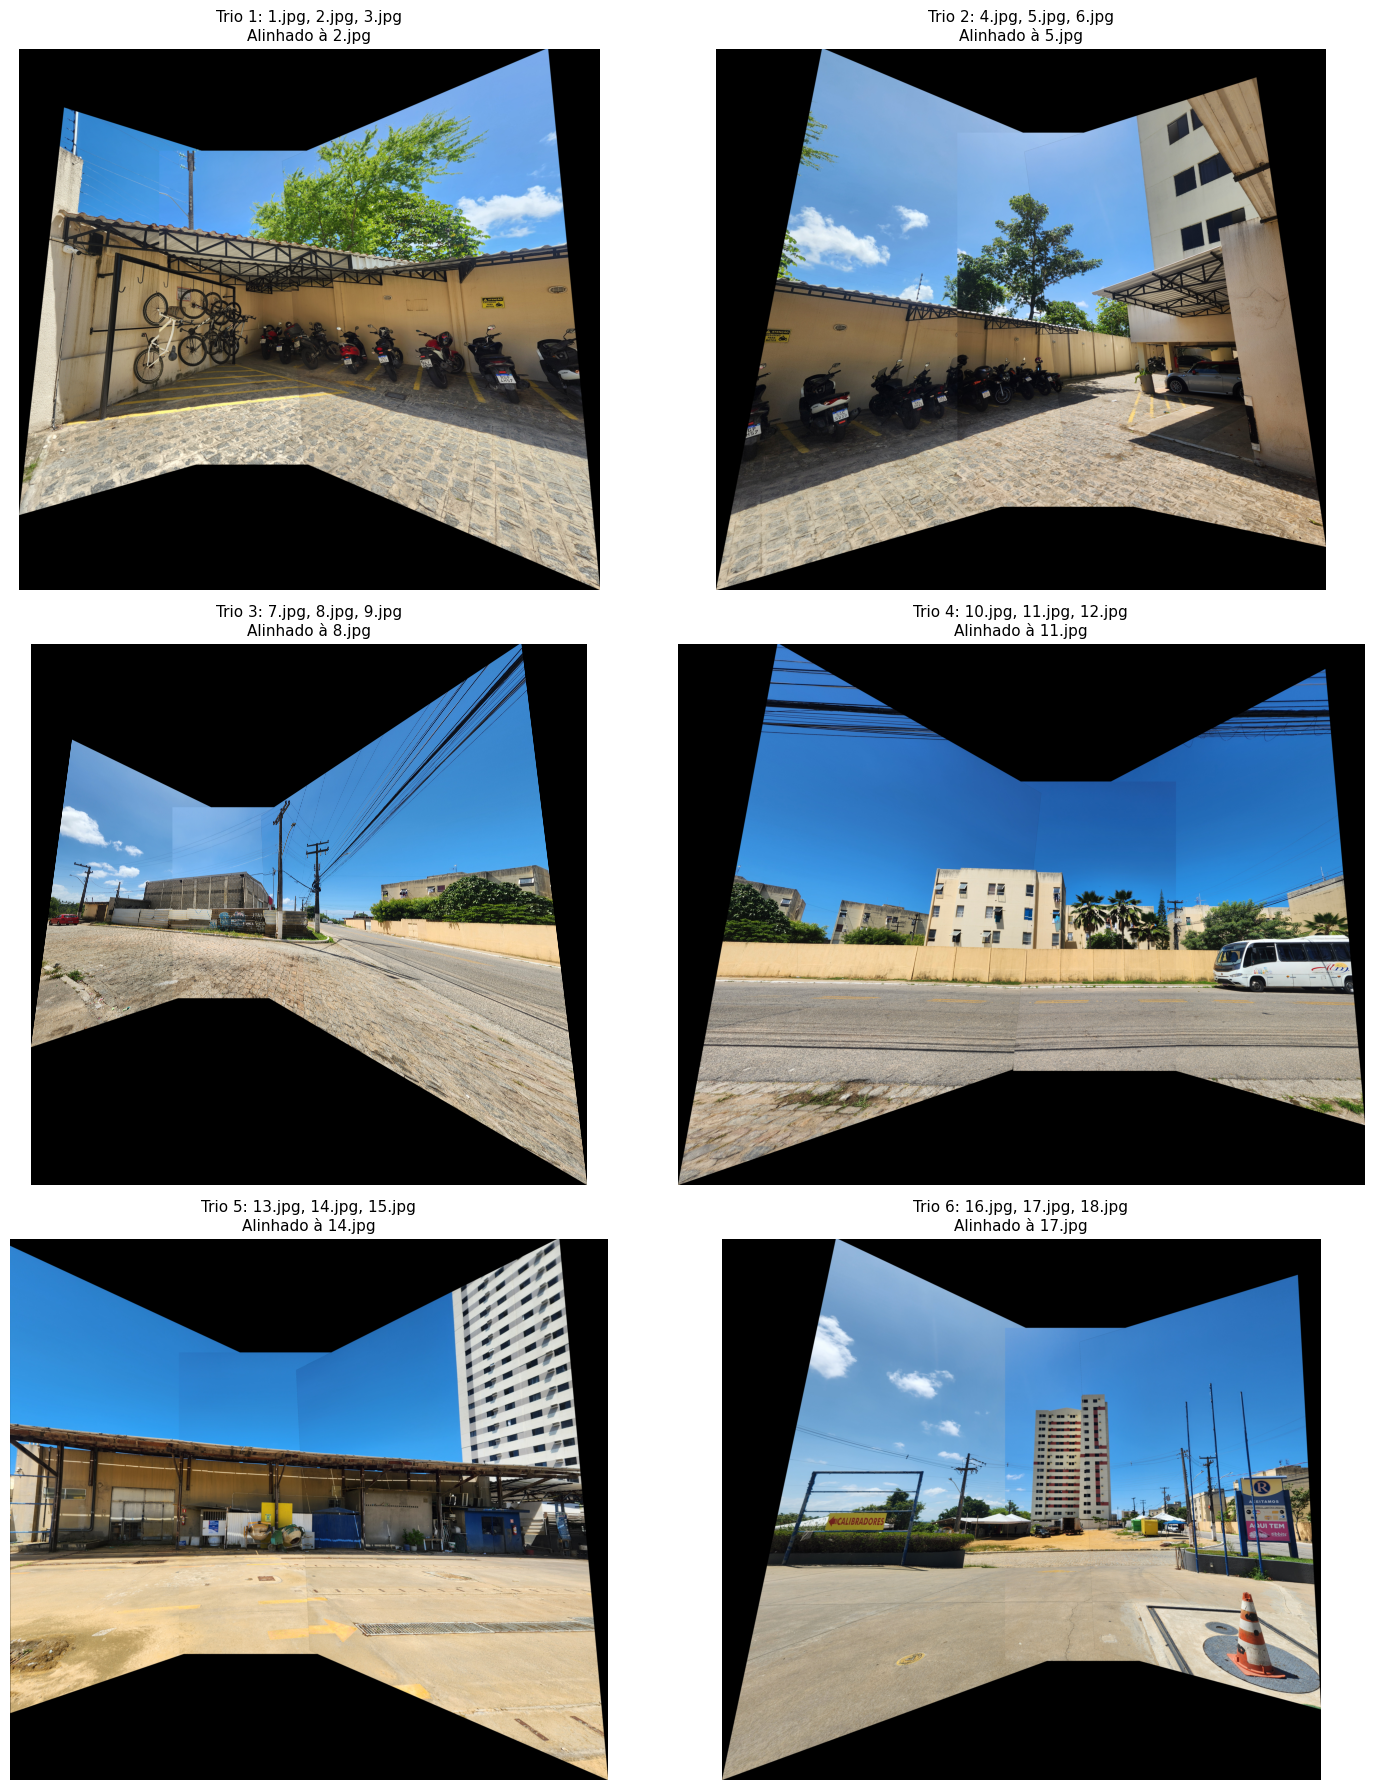

==================== Finalizando Questão 2 ====================


In [20]:
# --- Questão 2: Panorama com Trios ---

def calculate_trio_homographies(img1, img2, img3):
    """Calcula as homografias parciais H12 (img1->img2) e H23 (img2->img3)."""
    H12, _ = compute_homography(img1, img2, show_matches=False)
    if H12 is None:
        return None, None
    
    H23, _ = compute_homography(img2, img3, show_matches=False)
    if H23 is None:
        return H12, None
    
    return H12, H23

def get_composed_homographies(H12, H23, align_to_index):
    """
    Calcula as homografias necessárias para alinhar todas as 3 imagens
    ao plano da imagem no índice especificado (0, 1 ou 2).
    Retorna (H1_target, H2_target, H3_target).
    """
    H_identity = np.identity(3, dtype=np.float32)
    H21, H32, H13, H31 = None, None, None, None

    try:
        H21 = np.linalg.inv(H12)
    except np.linalg.LinAlgError:
        if align_to_index == 0: return None, None, None
    try:
        H32 = np.linalg.inv(H23)
    except np.linalg.LinAlgError:
        if align_to_index == 1 or align_to_index == 0: return None, None, None

    if H12 is not None and H23 is not None:
        H13 = H12 @ H23
    if H32 is not None and H21 is not None:
        H31 = H32 @ H21

    if align_to_index == 0:
        if H21 is None or H31 is None:
             return None, None, None
        return H_identity, H21, H31
    elif align_to_index == 1:
        if H12 is None or H32 is None:
            return None, None, None
        return H12, H_identity, H32
    elif align_to_index == 2:
        if H13 is None or H23 is None:
            return None, None, None
        return H13, H23, H_identity
    else:
        raise ValueError("align_to_index must be 0, 1, or 2")

def warp_and_stitch_trio(img1, img2, img3, H1_target, H2_target, H3_target):
    """Faz o warp das 3 imagens com base nas homografias alvo e as une."""
    images = [img1, img2, img3]
    homographies = [H1_target, H2_target, H3_target]
    shapes = [img.shape[:2] for img in images]

    all_corners_transformed = []
    for i, img in enumerate(images):
        h, w = shapes[i]
        corners = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
        if homographies[i] is not None:
            try:
                transformed = cv2.perspectiveTransform(corners, homographies[i])
                all_corners_transformed.append(transformed)
            except cv2.error:
                pass
        
    if not all_corners_transformed:
        return None

    all_corners = np.concatenate(all_corners_transformed, axis=0)

    x_min, y_min = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    x_max, y_max = np.int32(all_corners.max(axis=0).ravel() + 0.5)
    translation_dist = [-x_min, -y_min]
    H_translation = np.array([[1, 0, translation_dist[0]],
                              [0, 1, translation_dist[1]],
                              [0, 0, 1]], dtype=np.float32)

    panorama_width = x_max - x_min
    panorama_height = y_max - y_min

    if panorama_width <= 0 or panorama_height <= 0 or panorama_width > 15000 or panorama_height > 15000:
        return None

    panorama = np.zeros((panorama_height, panorama_width, 3), dtype=np.uint8)

    for i, img in enumerate(images):
        if homographies[i] is not None:
            H_combined = H_translation @ homographies[i]
            img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            try:
                warped_img = cv2.warpPerspective(img_bgr, H_combined, (panorama_width, panorama_height),
                                               borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))

                mask = np.all(warped_img != [0, 0, 0], axis=2)
                panorama[mask] = warped_img[mask]
            except cv2.error:
                pass

    panorama_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)
    return panorama_rgb

def process_image_trios(image_folder, trio_indices):
    """
    Processa um trio específico de imagens (baseado nos índices fornecidos)
    para gerar panoramas alinhados a cada imagem do trio.
    """
    images = load_images_from_folder(image_folder)
    if len(images) <= max(trio_indices):
        return []

    idx1, idx2, idx3 = trio_indices
    img1_name, img1 = images[idx1]
    img2_name, img2 = images[idx2]
    img3_name, img3 = images[idx3]

    H12, H23 = calculate_trio_homographies(img1, img2, img3)
    if H12 is None or H23 is None:
        return []

    panoramas = {}

    for align_idx in range(3):
        H1_target, H2_target, H3_target = get_composed_homographies(H12, H23, align_idx)

        if H1_target is None or H2_target is None or H3_target is None:
             continue

        panorama = warp_and_stitch_trio(img1, img2, img3, H1_target, H2_target, H3_target)

        if panorama is not None:
            panoramas[align_idx] = panorama

    return [{
        'names': (img1_name, img2_name, img3_name),
        'indices': trio_indices,
        'panoramas': panoramas
    }]

def find_image_indices_by_name(images, target_names):
    """Encontra índices de imagens pelo nome do arquivo"""
    indices = []
    image_names = [name for name, _ in images]
    
    for target in target_names:
        try:
            idx = image_names.index(target)
            indices.append(idx)
        except ValueError:
            return None
            
    return indices if len(indices) == len(target_names) else None

def process_sequential_trios(image_folder):
    """
    Processa imagens em trios sequenciais, de 3 em 3:
    (1-2-3, 4-5-6, 7-8-9, ...) até a imagem 18.
    """
    images = load_images_from_folder(image_folder)
    
    if len(images) < 3:
        print(f"Necessário pelo menos 3 imagens na pasta {image_folder}, encontradas {len(images)}")
        return []
        
    all_results = []
    max_image = min(18, len(images))
    
    # Processar trios em sequência: (0,1,2), (3,4,5), etc.
    for i in range(0, max_image - 2, 3):
        trio_indices = (i, i+1, i+2)
        print(f"Processando trio de índices {trio_indices}")
        
        # Usar a função existente para processar o trio específico
        trio_results = process_image_trios(image_folder, trio_indices)
        if trio_results:
            all_results.extend(trio_results)
    
    return all_results

def display_simplified_trio_results(trio_results):
    """Exibe apenas o panorama alinhado à imagem central de cada trio."""
    if not trio_results:
        return

    n_trios = len(trio_results)
    n_cols = 2
    n_rows = (n_trios + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
    
    if n_rows == 1:
        axes = np.array([axes])
    
    for i, result in enumerate(trio_results):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        names = result['names']
        indices = result['indices']
        panoramas = result['panoramas']
        
        MIDDLE_IMAGE_INDEX = 1
        if MIDDLE_IMAGE_INDEX in panoramas:
            panorama = panoramas[MIDDLE_IMAGE_INDEX]
            middle_img_name = names[1]
            
            ax.imshow(panorama)
            ax.set_title(f"Trio {i+1}: {names[0]}, {names[1]}, {names[2]}\nAlinhado à {middle_img_name}", fontsize=11)
            ax.axis('off')
        else:
            if panoramas:
                align_idx = list(panoramas.keys())[0]
                panorama = panoramas[align_idx]
                align_img_name = names[align_idx]
                
                ax.imshow(panorama)
                ax.set_title(f"Trio {i+1}: {names[0]}, {names[1]}, {names[2]}\nAlinhado à {align_img_name} (alternativo)", fontsize=11)
                ax.axis('off')
            else:
                ax.text(0.5, 0.5, 'Falha na criação do panorama', 
                      horizontalalignment='center', verticalalignment='center', 
                      transform=ax.transAxes, fontsize=12, color='red')
                ax.set_title(f"Trio {i+1}: {names[0]}, {names[1]}, {names[2]}\nFalha em todos os alinhamentos", fontsize=11)
                ax.axis('off')
    
    for i in range(len(trio_results), n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

print("="*20 + " Iniciando Questão 2 " + "="*20)
input_folder_q2 = "../img/task03/q2"

# Process the images - this returns a list of dictionaries
results_q2 = process_sequential_trios(input_folder_q2)

# Just display the results - don't reassign the variable
display_simplified_trio_results(results_q2)
print("="*20 + " Finalizando Questão 2 " + "="*20)

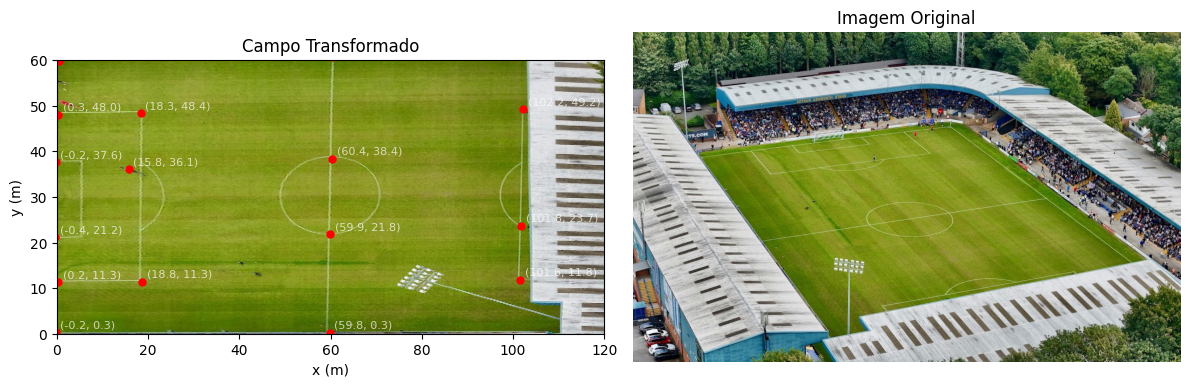

Coordenadas dos pontos em metros:
Ponto 1: (-0.22, 0.35)
Ponto 2: (0.39, 59.86)
Ponto 3: (0.24, 11.31)
Ponto 4: (0.26, 48.04)
Ponto 5: (-0.23, 37.63)
Ponto 6: (-0.37, 21.18)
Ponto 7: (18.77, 11.34)
Ponto 8: (18.35, 48.38)
Ponto 9: (59.78, 0.26)
Ponto 10: (59.92, 21.76)
Ponto 11: (60.36, 38.42)
Ponto 12: (60.40, 60.74)
Ponto 13: (101.55, 11.78)
Ponto 14: (102.22, 49.18)
Ponto 15: (101.78, 23.68)
Ponto 16: (15.75, 36.06)


In [11]:
soccer_img = cv2.imread('../img/task03/q3/soccer.jpg')
soccer_img_rgb = cv2.cvtColor(soccer_img, cv2.COLOR_BGR2RGB)

# Ponto cantos para homografia
positions = [
    [146, 275],
    [685, 208],
    [1149, 569],
    [461, 711]
]
pts_src = np.array(positions, dtype=np.float32)
field_width, field_height = 120, 60
scale = 5

# aqui rotação do campo
pts_dst = np.array([
    [0, 0],
    [0, field_height * scale],
    [field_width * scale, field_height * scale],
    [field_width * scale, 0],
], dtype=np.float32)

H, _ = cv2.findHomography(pts_src, pts_dst)
w_w, w_h = field_width * scale, field_height * scale
warped_img = cv2.warpPerspective(soccer_img, H, (w_w, w_h))
warped_img_rgb = cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB)

#coordenadas dos pontos que quero saber em metros
positions_mapping = [
    [149, 274],
    [685, 209],
    [256, 262],
    [586, 221],
    [495, 231],
    [347, 249],
    [297, 311],
    [640, 264],
    [280, 456],
    [512, 420],
    [681, 395],
    [891, 362],
    [540, 596],
    [953, 521],
    [678, 571],
    [523, 272]
]

field_coords = []
for pt in positions_mapping:
    p_array = np.array([pt], dtype=np.float32).reshape(-1, 1, 2)
    p_trans = cv2.perspectiveTransform(p_array, H)[0][0]
    # translading
    fx = p_trans[0] / scale
    fy = p_trans[1] / scale
    field_coords.append((fx, fy))

fig, (ax_trans, ax_orig) = plt.subplots(1, 2, figsize=(12, 5))

ax_trans.imshow(warped_img_rgb, extent=[0, field_width, 0, field_height], origin='lower')
for i, (fx, fy) in enumerate(field_coords, start=1):
    ax_trans.plot(fx, fy, 'ro', markersize=5)
    ax_trans.text(fx + 1, fy + 1, f"({fx:.1f}, {fy:.1f})",
                  color='white', fontsize=8, alpha=0.7)

ax_trans.set_xlim(0, field_width)
ax_trans.set_ylim(0, field_height)
ax_trans.set_xlabel("x (m)")
ax_trans.set_ylabel("y (m)")
ax_trans.set_title("Campo Transformado")

ax_orig.imshow(soccer_img_rgb)
ax_orig.set_title("Imagem Original")
ax_orig.axis("off")

plt.tight_layout()
plt.show()

print("Coordenadas dos pontos em metros:")
for i, (x, y) in enumerate(field_coords, start=1):
    print(f"Ponto {i}: ({x:.2f}, {y:.2f})")

In [35]:
import cv2
import numpy as np
import os

# === CONFIGURAÇÕES DO TABULEIRO ===
cols = 9  # número de cantos internos na horizontal
rows = 9  # número de cantos internos na vertical
square_size = 0.018  # tamanho de cada quadrado em metros (ex: 1.8 cm)

# === CRIA OS PONTOS 3D PADRÃO DO TABULEIRO ===
objp = np.zeros((rows * cols, 3), np.float32)
objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2) * square_size

# Arrays para armazenar os pontos do mundo e de imagem
objpoints = []
imgpoints = []

# === CAMINHO DAS IMAGENS ===
base_path = "../img/task03/q4"
front_image_path = os.path.join(base_path, "frente.jpg")

# === TENTA DETECTAR CANTOS NA IMAGEM DE FRENTE ===
img = cv2.imread(front_image_path)
if img is None:
    raise FileNotFoundError(f"Imagem não encontrada: {front_image_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_FAST_CHECK
ret, corners = cv2.findChessboardCorners(gray, (cols, rows), flags)

if ret:
    objpoints.append(objp)
    refined = cv2.cornerSubPix(
        gray, corners, (11, 11), (-1, -1),
        criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    )
    imgpoints.append(refined)

    cv2.drawChessboardCorners(img, (cols, rows), refined, ret)
    cv2.imshow("Cantos detectados", img)
    cv2.waitKey(500)
    cv2.destroyAllWindows()

# === CALIBRA A CÂMERA ===
ret, cameraMatrix, distCoeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None
)

if not ret:
    raise RuntimeError("Falha na calibração da câmera.")

print("Matriz Intrínseca:")
print(cameraMatrix)
print("\nCoeficientes de Distorção:")
print(distCoeffs)

# === GERA CÍRCULO 3D ===
W = (cols - 1) * square_size
H = (rows - 1) * square_size
r = 0.5 * W
center = np.array([1.5 * W, 1.5 * H, 0])

theta = np.linspace(0, 2*np.pi, 100)
circle_3D = np.array([
    r * np.cos(theta) + center[0],
    r * np.sin(theta) + center[1],
    np.zeros_like(theta)
]).T

# === PROJETA O CÍRCULO NA IMAGEM DE FRENTE ===
img_with_circle = cv2.imread(front_image_path)
imgpts, _ = cv2.projectPoints(circle_3D, rvecs[0], tvecs[0], cameraMatrix, distCoeffs)
imgpts = imgpts.reshape(-1, 2).astype(int)

for j in range(len(imgpts) - 1):
    cv2.line(img_with_circle, tuple(imgpts[j]), tuple(imgpts[j + 1]), (0, 0, 255), 2)
cv2.line(img_with_circle, tuple(imgpts[-1]), tuple(imgpts[0]), (0, 0, 255), 2)

cv2.imshow("Círculo Projetado na Imagem", img_with_circle)
cv2.waitKey(0)
cv2.destroyAllWindows()


error: OpenCV(4.11.0) /private/var/folders/zb/fsvx994s2g54rx2zz2nh6sp40000gn/T/pip-install-1kisax0g/opencv-python_73e27ae3737a46c3853d2d66fa1bf6ce/opencv/modules/calib3d/src/calibration.cpp:1379: error: (-215:Assertion failed) nimages > 0 in function 'calibrateCameraRO'
